# Which content pages should a FlyRank editor review first?

**Author:** Vibhanshu · **Lane:** content performance review · **Status:** historical research and decision-support

## Abstract

I asked whether earlier search measurements could help a FlyRank editor choose which pages to review when review time is limited. I used the March 2026 partition of the pseudonymized FlyRank internship warehouse, with 57,459 pages across 32 clients that had complete search coverage in both study windows. I compared a fixed visibility-and-CTR rule with logistic regression using five earlier-window features and five-fold validation grouped by client. Across the 23 clients with full 20-page review lists, the model's mean precision@20 was 57.17%, compared with 38.26% for the rule and a 40.23% mean decline rate in those clients' eligible pages. The output is a human-reviewed queue for investigating search performance; this one-month offline comparison does not establish future forecasting performance or show that refreshing a page improves traffic.

## 1. Introduction: the FlyRank content decision

A FlyRank editor may have time to inspect 20 pages for a client but far more pages with search activity. The useful question is where to start: which pages deserve a closer look at query intent, factual accuracy, snippets or internal links? A ranking can make that first review more focused, while the editor still decides whether any change is justified.

One row is one pseudonymized client–page pair. My output is a rank within that client's queue, a reason code and a suggested inspection action. A wrong recommendation wastes review time or encourages an unnecessary edit; a missed page can delay investigation of a real search-performance problem. Those costs are why I compare the model with an understandable rule and keep human review in the loop.

This is my FlyRank case study: prioritizing content review under a small review budget. The target is a later drop in impressions, not the value of a refresh or an assessment of writing quality. Data can help combine search signals, but the final decision needs page context that this release does not contain.


## 2. Data and exclusions

I used `fact_content_daily_performance`, March 2026, from the [FlyRank internship warehouse](https://huggingface.co/datasets/FlyRank/internship-warehouse), pinned to revision `50cbf7c3909d07be4d1b5906b4d09e882e5acbf2`. The partition contains 9,841,378 daily rows; 3,611,061 have `gsc_data_available IS TRUE`. Daily rows aggregate to one client–page pair for this experiment.

Features use March 1–14. March 18 is the assumed review date, allowing three full days for reporting delay; this is an assumption rather than a measured warehouse service guarantee. Outcomes use March 18–31, so the two compared windows each contain 14 days.

Pages need 14 usable earlier GSC days and at least 100 earlier impressions. This leaves 60,534 pages; 57,459 have complete later coverage and a usable target, while 3,075 have unknown outcomes. Missing availability is excluded rather than treated as zero activity. The final June partition remains untouched.

The public paper includes aggregates and a summary chart, without client names, page URLs, raw search queries or row-level exports. Pseudonymous IDs are used only for grouping, joins, ordering ties and validation. Future measurements, the decline label, starter-data trend fields and content age are excluded from model inputs.


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

needed = {"duckdb": "duckdb", "huggingface_hub": "huggingface_hub", "sklearn": "scikit-learn",
          "pyarrow": "pyarrow", "matplotlib": "matplotlib", "pandas": "pandas"}
missing = [package for module, package in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "work/lane_utils.py").is_file()), None)
if root is None:
    if importlib.util.find_spec("google.colab") is None:
        raise RuntimeError("Open this notebook inside your repository checkout.")
    root = Path("/content/FlyrankAI-Internship")
    if not root.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
            "https://github.com/vibhanshu-s/FlyrankAI-Internship.git", str(root)])
sys.path.insert(0, str(root / "work"))
import lane_utils as u
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pages = u.load_pages(root)
experiment = u.labelled_pages(pages)
train_index, test_index = u.grouped_split(experiment)
training = experiment.iloc[train_index].copy()
test = experiment.iloc[test_index].copy()
print(f"March review pool: {len(pages):,} pages; known outcomes: {len(experiment):,}; unknown: {pages.future_decline.isna().sum():,}.")
print(f"Fixed client split: {len(training):,} training pages / {len(test):,} test pages.")
print("Features stop March 14; assumed decision March 18; labels use March 18–31. June remains sealed.")

March review pool: 60,534 pages; known outcomes: 57,459; unknown: 3,075.
Fixed client split: 14,070 training pages / 43,389 test pages.
Features stop March 14; assumed decision March 18; labels use March 18–31. June remains sealed.


## 3. Methodology

The proxy is `later_impressions < 0.8 * earlier_impressions`: a drop greater than 20% between two equal-length windows. This makes the task binary scoring followed by within-client ranking. It is a search-visibility proxy, not an intervention outcome.

The five features are log(1 + earlier impressions), log(1 + earlier clicks), earlier CTR in percentage units, impression-weighted earlier position and the number of earlier days with search activity. Position zero means missing measurement. All five use only the earlier window; active-search days is constant at 14 in the filtered frame and contributes no discrimination.

The frozen Week 4 rule scores log(1 + earlier impressions), doubled when CTR is below 0.5% and position is between 1 and 20. Its single reason code is `visible_page_review`, and its action is `review_search_performance`. This favors visible pages with weak click capture, but volume alone showed a mixed relationship with later decline in the training signal audit.

The model is logistic regression with C=1, a training-fold median imputer and a training-fold standard scaler. I chose it for a readable, modest comparison rather than adding complexity without evidence. No IDs, labels or later measurements enter the pipeline; seed 42 is used where randomness applies.

Week 5 used a fixed client-held-out split: 24 training clients and eight test clients. Week 6 compared a deliberately weaker row-random split with client holdout, then used five-fold GroupKFold so each of the 32 clients received predictions from a model trained on other clients. Both methods rank exactly the same eligible pages in each comparison. Precision@20 averages each full client's top-20 hit rate equally; nine clients with fewer than 20 eligible pages are reported separately.

The leakage audit also added one copy of the future label as a deliberate positive control: AUC reached 1.00. That column was deleted, and the honest five-feature model was retained. This demonstrates how a label-derived input can create a misleading score; it does not establish that every possible leakage source has been ruled out.


In [2]:
import json
from sklearn.model_selection import GroupKFold
X = experiment[u.FEATURES]
y = experiment.future_decline.astype(int)
oof = np.full(len(experiment), np.nan)
for train_rows, test_rows in GroupKFold(n_splits=5).split(X, y, experiment.client_hash_id):
    assert set(experiment.iloc[train_rows].client_hash_id).isdisjoint(set(experiment.iloc[test_rows].client_hash_id))
    assert np.isnan(oof[test_rows]).all()
    model = u.make_model()
    model.fit(X.iloc[train_rows], y.iloc[train_rows])
    oof[test_rows] = model.predict_proba(X.iloc[test_rows])[:, 1]
assert np.isfinite(oof).all()
results = {"Frozen rule / all OOF pages": u.evaluate(experiment, u.rule_score(experiment)),
           "Logistic regression / all OOF pages": u.evaluate(experiment, oof)}
receipt = json.loads((root / "work/outputs/w07_playbook_metrics.json").read_text())
assert receipt["data_fingerprint"] == u.fingerprint(pages)
for method, metrics in results.items():
    for key, value in metrics.items():
        expected = receipt["validated_metrics"][method][key]
        assert np.isclose(value, expected) if value is not None else expected is None
display(u.summary_table(results))
print("Fresh grouped predictions reproduce the committed playbook metrics.")


,macro_precision_at_20,macro_base_rate_same_clients,roc_auc,average_precision,full_queue_clients,short_queue_clients,pages
Frozen rule / all OOF pages,0.3826,0.4023,0.5170,0.3685,23.0,9.0,57459.0
Logistic regression / all OOF pages,0.5717,0.4023,0.5847,0.4397,23.0,9.0,57459.0


Fresh grouped predictions reproduce the committed playbook metrics.


## 4. Results and interpretation

The table below is the five-fold, client-grouped comparison used by the playbook. It covers 57,459 pages from 32 clients; the primary precision metric covers 23 full client lists. The nine shorter lists have a mean precision of 26.67% for both methods and do not enter that primary average.

| Method | Mean precision@20 | Mean eligible-page decline rate, same 23 clients | Pooled ROC AUC | Pooled average precision |
|---|---:|---:|---:|---:|
| Frozen rule | 38.26% | 40.23% | 0.5170 | 0.3685 |
| Logistic regression | 57.17% | 40.23% | 0.5847 | 0.4397 |

![Client-grouped model and baseline comparison](figures/model_vs_baseline_precision.png)

*The model increased mean precision@20 by 18.91 percentage points in this historical comparison, with positive gains in four of five folds. Ranking and review budgets are within clients; the pooled discrimination metrics are supplementary.*

Resampling paired results from the 23 full-list clients 2,000 times with seed 42 gives a 95% interval of 11.52–26.74 percentage points for the mean gain. This interval is conditional on the fitted fold models and does not include refitting or month-to-month uncertainty. Week 5's separate eight-client holdout gave 57.14% for the model and 37.14% for the same rule; these are different evaluation inventories, so their numbers should not be mixed.

In the Week 5 permutation check, earlier clicks and impressions carried more discrimination than CTR or position; constant active-search days carried none. These features share information, so their importance and coefficient signs do not identify causal levers. Low CTR within position buckets showed a directional association in the training audit, while impression-volume buckets were mixed.

Real failure examples in the validation notebook include selected pages without a later decline and declining pages outside the top 20. Query-demand shifts, measurement changes or normal variation could explain some errors, but the available release does not establish their causes. A high score therefore means “inspect first,” not “this page needs rewriting.”


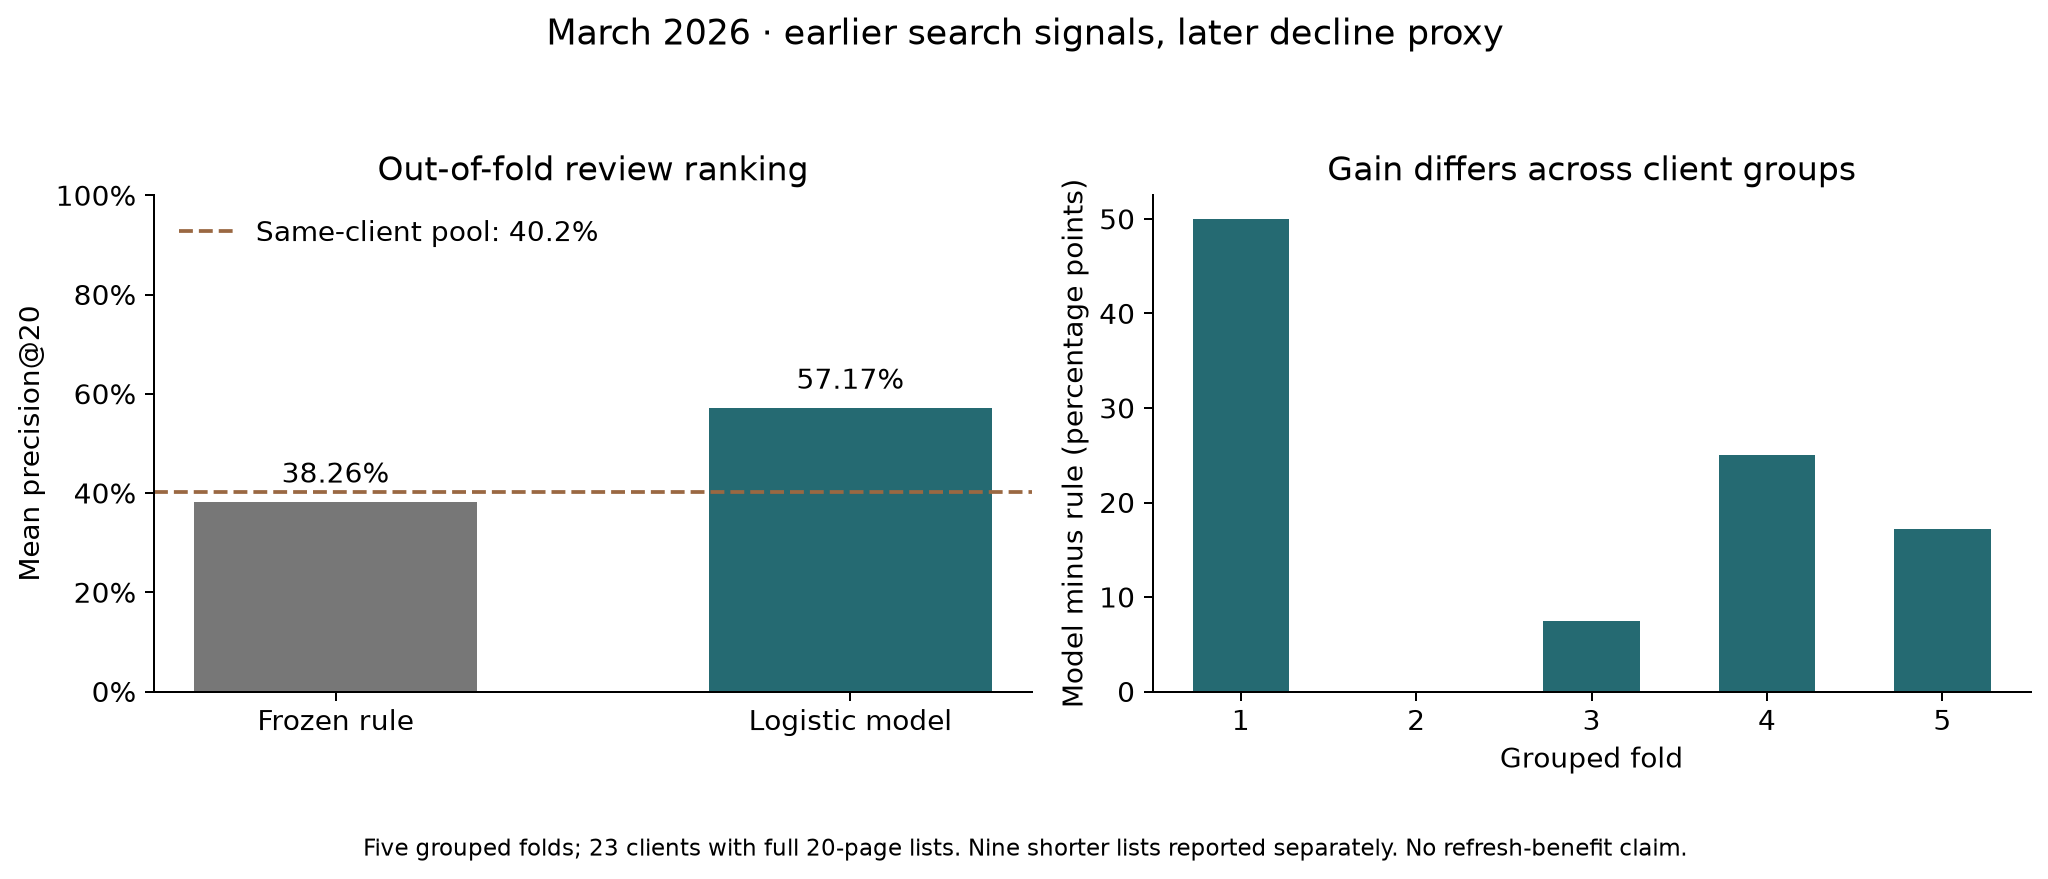

Chart scope: 23 full client queues, nine short queues separate; one historical month.


In [3]:
from IPython.display import Image
display(Image(filename=str(root / "work/figures/model_vs_baseline_precision.png")))
print("Chart scope: 23 full client queues, nine short queues separate; one historical month.")


## 5. Limitations and careful claims

This is one previously inspected development month, not an untouched temporal test. Although each validation client is unseen during fitting, the models learn other clients' later March outcomes; they would not have been available on March 18. A forecasting claim needs an earlier completed training period and an untouched later evaluation period before any operational use.

The evaluated population is selected by complete future coverage. The 3,075 unknown outcomes are not negatives, and the separate coverage-follow-up queue is retrospective, not a March 18 risk forecast. Client sizes are uneven; only 23 clients support full top-20 lists. Precision measures a decline proxy, not editor acceptance, avoided losses or successful changes.

The earlier-impression denominator also appears in the target, so regression to the mean may contribute to the observed relationships. No content age, refresh history, intervention or revenue outcome was modeled. A drop in impressions cannot establish content decay, and the result cannot show that refreshing content restores traffic or earns money.


## 6. Ranked recommendations and human review

Use the validated scores to organize a historical, within-client review exercise. The exported playbook contains 57,459 scored pages and 504 top-of-list review slots across the 32 clients; other pages are marked for monitoring. The pseudonymous release cannot identify real production pages, so this public queue is a research artifact.

| Earlier-signal archetype | Reason code | First human action |
|---|---|---|
| Position 1–20 and CTR below 0.5% | `low_ctr_at_visible_position` | Inspect snippet and query intent |
| Position above 20 | `limited_search_position` | Inspect relevance and internal links |
| Other measured visibility | `visible_page_review` | Check facts and search context |
| Position unavailable | `missing_position` | Verify measurement |

These are transparent routing heuristics, not separately validated diagnoses. Before editing, an authorized reviewer should verify reporting coverage, page purpose, relevant query context and the current content. A refresh is a candidate only when the page actually has stale facts or a clear intent mismatch; impressions alone do not establish that need. Leave a useful page unchanged when the evidence does not justify an edit.

Assuming 15 minutes for a first inspection, 20 reviews cost about five hours per client. The measured gain corresponds to roughly 3.8 more decline-proxy hits per full 20-page list on average; it is not a count of successful edits or an estimate of financial value. Record review acceptance and actual time before making a resource decision.

Do not automate rewriting, publishing, deleting, merging pages, canonical changes, reidentification or spending. The playbook is non-production and requires human review. Its monitoring suggestions are proposals: investigate missing position above 5%, unknown outcomes above 10%, or a decline-rate shift above 10 percentage points; pause if the model trails the rule for two completed periods. Investigate reviewer acceptance below 50% over two cycles with at least 20 reviews. Check measurement and context first; retraining requires reviewed labels and a new grouped and temporal evaluation, never an automatic job.


## 7. Artifacts and reproducibility

The [repository](https://github.com/vibhanshu-s/FlyrankAI-Internship) contains the executed [baseline notebook](https://github.com/vibhanshu-s/FlyrankAI-Internship/blob/main/work/notebooks/w04_baseline_score.ipynb), [model notebook](https://github.com/vibhanshu-s/FlyrankAI-Internship/blob/main/work/notebooks/w05_model.ipynb), [validation audit](https://github.com/vibhanshu-s/FlyrankAI-Internship/blob/main/work/notebooks/w06_validation_audit.ipynb) and [action playbook](https://github.com/vibhanshu-s/FlyrankAI-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb). The [capstone notebook](https://github.com/vibhanshu-s/FlyrankAI-Internship/blob/main/work/notebooks/capstone.ipynb) recomputes the grouped result and checks it against the committed receipts.

Clone the repository and open the notebooks in order from Week 4 through the capstone. Request access to the pinned warehouse release and supply a read token through the `HF_TOKEN` environment variable or a Colab Secret; never paste it into code. Run every notebook top to bottom. The bootstrap installs missing analysis packages; `work/lane_utils.py` loads the March partition and caches it locally. Week 7 regenerates `work/outputs/action_playbook_queue.csv` and `coverage_followup_queue.csv`; both stay out of git.

Metric receipts are committed as `work/outputs/w04_baseline_metrics.json` through `w07_playbook_metrics.json`, with contract, data fingerprints and source hashes. The chart is committed under `work/figures/`. The recorded analysis environment was Python 3.12.14, pandas 3.0.1, NumPy 2.5.3 and scikit-learn 1.9.1; library changes can alter results, and receipt assertions expose such differences.

To rebuild the public page from the capstone markdown and committed figure, install `work/paper_requirements.txt` and run `python work/scripts/build_paper.py` from the repository root. The builder checks the displayed metrics against the Week 7 receipt and copies the chart into the served `docs/figures/` folder. GitHub Pages serves `docs/` from `main`.

## 8. Acknowledgments and data credit

Built on the FlyRank ML Internship dataset, with data credit to [FlyRank](https://flyrank.ai) and the [warehouse release](https://huggingface.co/datasets/FlyRank/internship-warehouse). The [FlyRank SEO research paper, March 2026](https://github.com/flyrank-bih/flyrank-ml-internship-starter/blob/main/docs/flyrank-seo-research-march-2026.pdf) informed the methodology questions in Week 6; its task and labels differ from this experiment. AI assisted with drafting and code; the committed notebook outputs and checks document the validation performed here. This public release does not provide the context needed to assess individual clients or publish content changes.


In [4]:
import hashlib
for name, digest in receipt["source_receipts_sha256"].items():
    assert hashlib.sha256((root / "work/outputs" / name).read_bytes()).hexdigest() == digest
assert receipt["main_queue_rows"] == len(experiment)
assert receipt["no_automatic_content_changes"] and receipt["no_causal_refresh_or_revenue_claim"]
assert len(u.FEATURES) == 5 and not any("later" in f or "future" in f for f in u.FEATURES)
print("Self-check passed: receipts match, five earlier features, human review, explicit limits.")


Self-check passed: receipts match, five earlier features, human review, explicit limits.


## 9. Five-minute demo outline

- **0:00–0:45 — Question.** “If a FlyRank editor can inspect 20 pages for a client, where should they start?” Explain the review budget and the cost of wasting it on unnecessary edits.
- **0:45–1:45 — Data and method.** Introduce 57,459 eligible pages from 32 clients in March 2026. Explain the two 14-day windows, the greater-than-20% impression-drop proxy, the five earlier features, the fixed rule and logistic regression. Each client's predictions come from a model trained on other clients.
- **1:45–2:45 — One chart.** Show `work/figures/model_vs_baseline_precision.png`. Point to precision@20: rule 38.26%, model 57.17%, same-client eligible-page decline rate 40.23%. Explain that the primary average covers 23 full queues and nine shorter queues are separate.
- **2:45–3:45 — One honest result.** State the 18.91-point observed gain, then the limit: one development month, no temporal deployment test and no evidence that a refresh improves traffic. Mention one selected page without a decline and one missed declining page from the validation audit.
- **3:45–5:00 — One recommendation.** Use a within-client queue to choose human inspections. Show how low CTR at a visible position routes to snippet and intent review; the reviewer checks actual page context before deciding. Close with the next step: earlier-period training and untouched later evaluation, followed by measured editor acceptance. No automatic publishing.


## 10. Two shareable cuts

### Short social post

I built a content-review ranking experiment for the FlyRank internship, starting with a transparent rule before trying logistic regression. Using March 2026 search data and validation grouped by client, mean precision@20 was 57.17% for the model versus 38.26% for the rule across 23 full client queues. The comparison chart and methodology are in my paper: https://vibhanshu-s.github.io/FlyrankAI-Internship/ This is one-month decision-support research: it does not show future performance or prove that refreshing content improves traffic. My main takeaway was to keep future outcomes out of features and make every recommendation earn a human review.

### Employer-facing summary — three sentences

I built a reproducible content-review ranking workflow with a rule baseline, logistic regression, a leakage audit and a human-reviewed action playbook. I used pseudonymized March 2026 FlyRank warehouse search data, evaluating 57,459 pages across 32 clients with five-fold validation grouped by client. Across 23 full client queues, mean precision@20 was 57.17% versus 38.26% for the rule; the result supports further review-prioritization research, with temporal validation and editor feedback needed before operational use.
